# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [3]:
!pip install mat73 h5py

In [5]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [6]:
# 데이터 경로 설정
DATA_DIR = "./archive"

# 폴더 내 .mat 파일 목록 가져오기 및 정렬
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.mat')])

print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    # 파일별 상대 경로 생성
    file_path = os.path.join(DATA_DIR, f)
    
    # 파일 크기 계산 (GB 단위)
    size_gb = os.path.getsize(file_path) / (1024**3)
    print(f"   {f}  ({size_gb:.2f} GB)")

데이터 경로 : ./archive
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.82 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.88 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.08 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.01 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [8]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')
# batch2_path = os.path.join(DATA_DIR, '2018-02-20_batchdata_updated_struct_errorcorrect.mat')
# batch3_path = os.path.join(DATA_DIR, '2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat')
# batch4_path = os.path.join(DATA_DIR, '2018-04-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [9]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [10]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [11]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [12]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [13]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [14]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [15]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [16]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

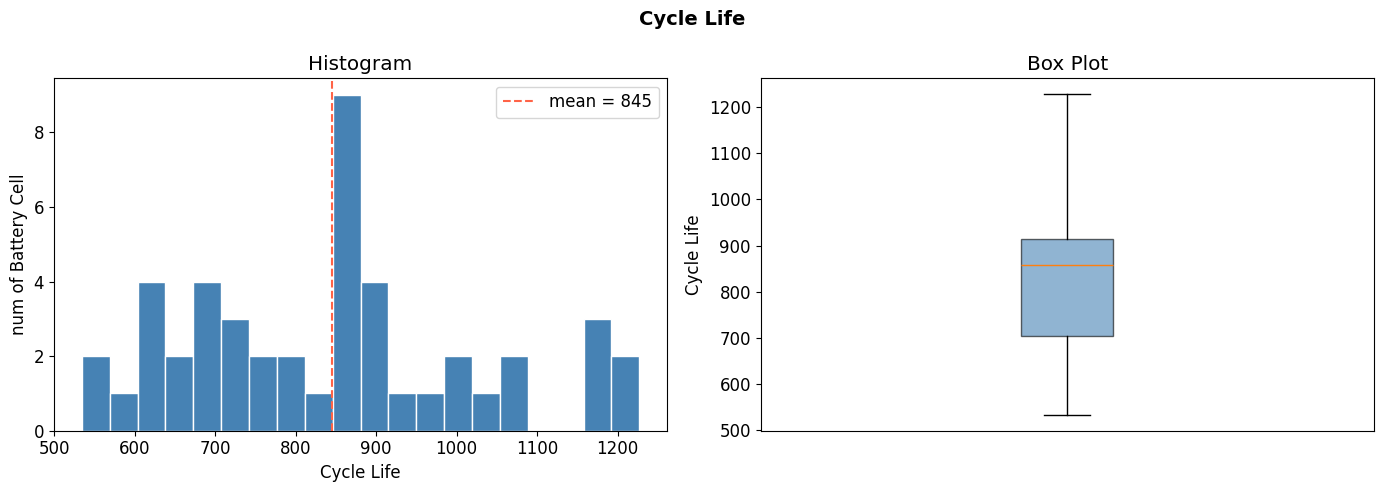

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [17]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

In [20]:
!pip install seaborn

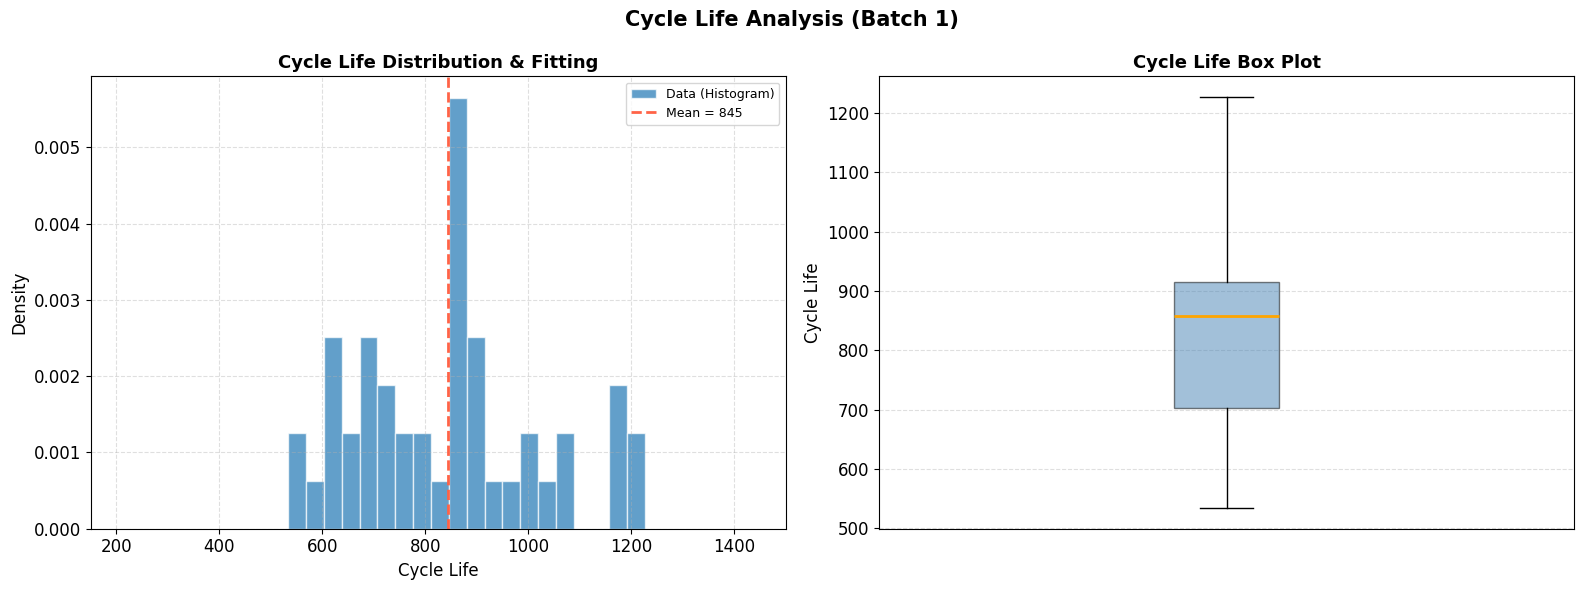

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64

[Life_Status 그룹별 셀 개수 및 비율]
Normal (500~999) : 36개 (78.3%)
Long (>=1000)   : 10개 (21.7%)


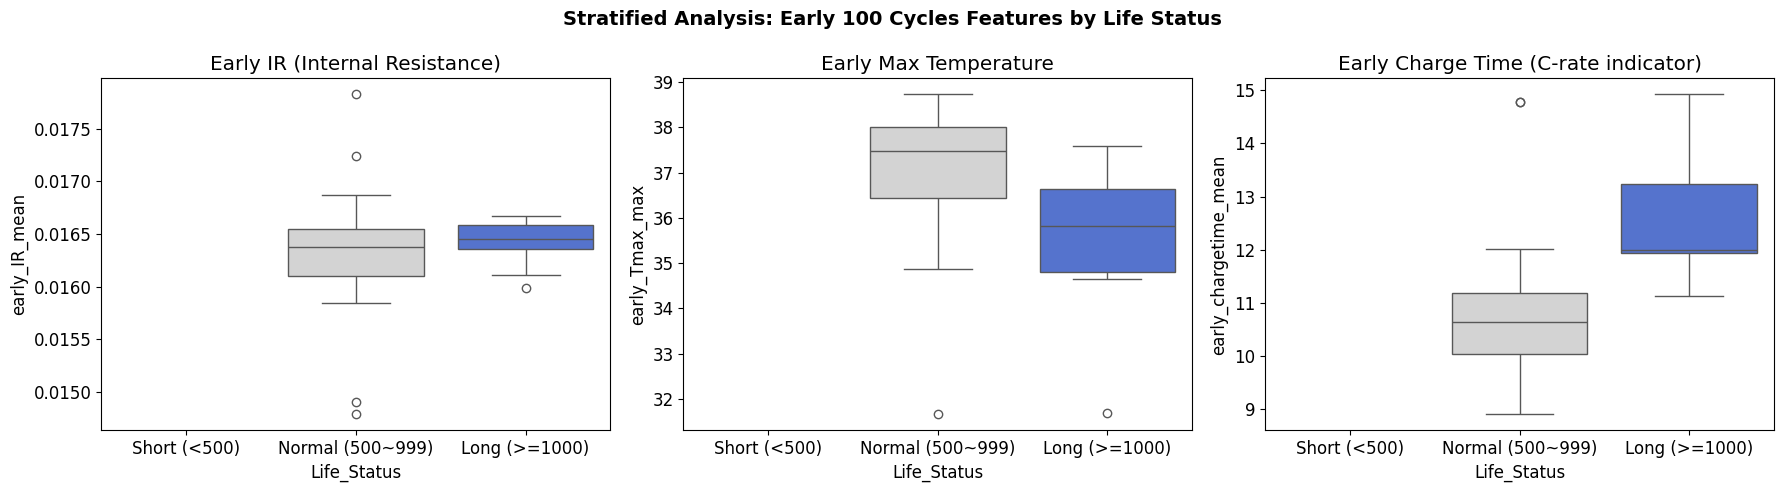


[다변량 교차 분석] 최하위 단수명 셀 (Bottom 5)
 cell_id  cycle_life charging_policy  early_IR_mean  early_Tmax_max
      20         534  5.4C(80%)-5.4C       0.014906       35.504932
      21         559  5.4C(80%)-5.4C       0.014788       37.615559
      45         599    8C(35%)-3.6C       0.016508       37.855122
      44         616    8C(35%)-3.6C       0.017240       36.804283
      38         617    7C(40%)-3.6C       0.016050       37.995705

[극단값 그룹 T-test] 상위 10% vs 하위 10% 초기 내부저항(IR) 비교
• 상위 10% (Longest Life) 초기 IR 평균 : 0.01636 Ω
• 하위 10% (Shortest Life) 초기 IR 평균: 0.01590 Ω
• T-statistic : 0.966
• p-value     : 0.38413
=> [결론] 두 그룹 간의 초기 IR 평균 차이는 통계적으로 유의미하지 않습니다.


In [71]:
import seaborn as sns
from scipy import stats

# =====================================================================
# 1. Cycle Life 분포의 심층 분석 (150 ~ 2,300 구간)
# =====================================================================
# 1. 시각화 영역 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 데이터 준비
data_life = cycle_life_df['cycle_life'].values
mean_val = np.mean(data_life)

# =====================================================================
# 좌측 그래프: Histogram & Reliability Fitting (스타일 수정)
# =====================================================================
# 히스토그램 (Density 기준)
axes[0].hist(data_life, bins=20, density=True, edgecolor='white', alpha=0.7, label='Data (Histogram)')

# 평균선 추가 (앞선 스타일 반영)
axes[0].axvline(mean_val, color='tomato', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.0f}')

# 분포 적합 곡선 (Fitting)
x_range = np.linspace(150, 1500, 1000)

# 꾸미기
axes[0].set_xlim(150, 1500)
axes[0].set_title('Cycle Life Distribution & Fitting', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)

# =====================================================================
# 우측 그래프: Box Plot (스타일 수정)
# =====================================================================
axes[1].boxplot(data_life, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='orange', linewidth=2),
                flierprops=dict(marker='o', markersize=6, alpha=0.8))

# 꾸미기
axes[1].set_title('Cycle Life Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([]) # X축 라벨 제거
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

# 전체 타이틀 및 레이아웃 조정
plt.suptitle('Cycle Life Analysis (Batch 1)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 요약 통계량 출력
print(cycle_life_df['cycle_life'].describe().round(1))

# =====================================================================
# 2. 장수명(>1,000) vs 단수명(<700) 비율 및 계층화 분석 (Stratified Analysis)
# =====================================================================
# 파생 변수 생성 (Life_Status)
def categorize_life(life):
    if life >= 1000:
        return 'Long (>=1000)'
    elif life < 500:
        return 'Short (<500)'
    else:
        return 'Normal (500~999)'

cycle_life_df['Life_Status'] = cycle_life_df['cycle_life'].apply(categorize_life)

print("\n" + "="*50)
print("[Life_Status 그룹별 셀 개수 및 비율]")
print("="*50)
status_counts = cycle_life_df['Life_Status'].value_counts()
status_ratios = cycle_life_df['Life_Status'].value_counts(normalize=True) * 100
for idx in status_counts.index:
    print(f"{idx:15s} : {status_counts[idx]:2d}개 ({status_ratios[idx]:.1f}%)")

# 초기 사이클 특성 (1~100) 추출: 그룹 간 차이를 보기 위해 df에서 집계
early_features = df[df['cycle'] <= 100].groupby('cell_id').agg(
    early_IR_mean=('IR', 'mean'),
    early_Tmax_max=('Tmax', 'max'),
    early_chargetime_mean=('chargetime', 'mean')
).reset_index()

# 특성 결합
merged_df = pd.merge(cycle_life_df, early_features, on='cell_id')

# 그룹별 초기 징후 Boxplot 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
order_list = ['Short (<500)', 'Normal (500~999)', 'Long (>=1000)']
palette_dict = {'Short (<500)': 'tomato', 'Normal (500~999)': 'lightgray', 'Long (>=1000)': 'royalblue'}

sns.boxplot(data=merged_df, x='Life_Status', y='early_IR_mean', order=order_list, palette=palette_dict, ax=axes[0])
axes[0].set_title('Early IR (Internal Resistance)')

sns.boxplot(data=merged_df, x='Life_Status', y='early_Tmax_max', order=order_list, palette=palette_dict, ax=axes[1])
axes[1].set_title('Early Max Temperature')

sns.boxplot(data=merged_df, x='Life_Status', y='early_chargetime_mean', order=order_list, palette=palette_dict, ax=axes[2])
axes[2].set_title('Early Charge Time (C-rate indicator)')

plt.suptitle('Stratified Analysis: Early 100 Cycles Features by Life Status', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# =====================================================================
# 3. 이상치 셀 식별 및 초기 징후(Extreme Group) T-test 검정
# =====================================================================
print("\n" + "="*50)
print("[다변량 교차 분석] 최하위 단수명 셀 (Bottom 5)")
print("="*50)
bottom_5 = merged_df.nsmallest(5, 'cycle_life')
print(bottom_5[['cell_id', 'cycle_life', 'charging_policy', 'early_IR_mean', 'early_Tmax_max']].to_string(index=False))

print("\n" + "="*50)
print("[극단값 그룹 T-test] 상위 10% vs 하위 10% 초기 내부저항(IR) 비교")
print("="*50)
# 상/하위 10% 임계값
top_10_thresh = merged_df['cycle_life'].quantile(0.9)
bot_10_thresh = merged_df['cycle_life'].quantile(0.1)

top_10_group = merged_df[merged_df['cycle_life'] >= top_10_thresh]
bot_10_group = merged_df[merged_df['cycle_life'] <= bot_10_thresh]

# Welch's T-test (등분산성 가정 X)
t_stat, p_val = stats.ttest_ind(top_10_group['early_IR_mean'], bot_10_group['early_IR_mean'], equal_var=False)

print(f"• 상위 10% (Longest Life) 초기 IR 평균 : {top_10_group['early_IR_mean'].mean():.5f} Ω")
print(f"• 하위 10% (Shortest Life) 초기 IR 평균: {bot_10_group['early_IR_mean'].mean():.5f} Ω")
print(f"• T-statistic : {t_stat:.3f}")
print(f"• p-value     : {p_val:.5f}")

if p_val < 0.05:
    print("=> [결론] 두 그룹 간의 초기 IR 평균 차이는 통계적으로 매우 유의미합니다. (초기 내부저항이 수명의 결정적 징후임)")
else:
    print("=> [결론] 두 그룹 간의 초기 IR 평균 차이는 통계적으로 유의미하지 않습니다.")

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

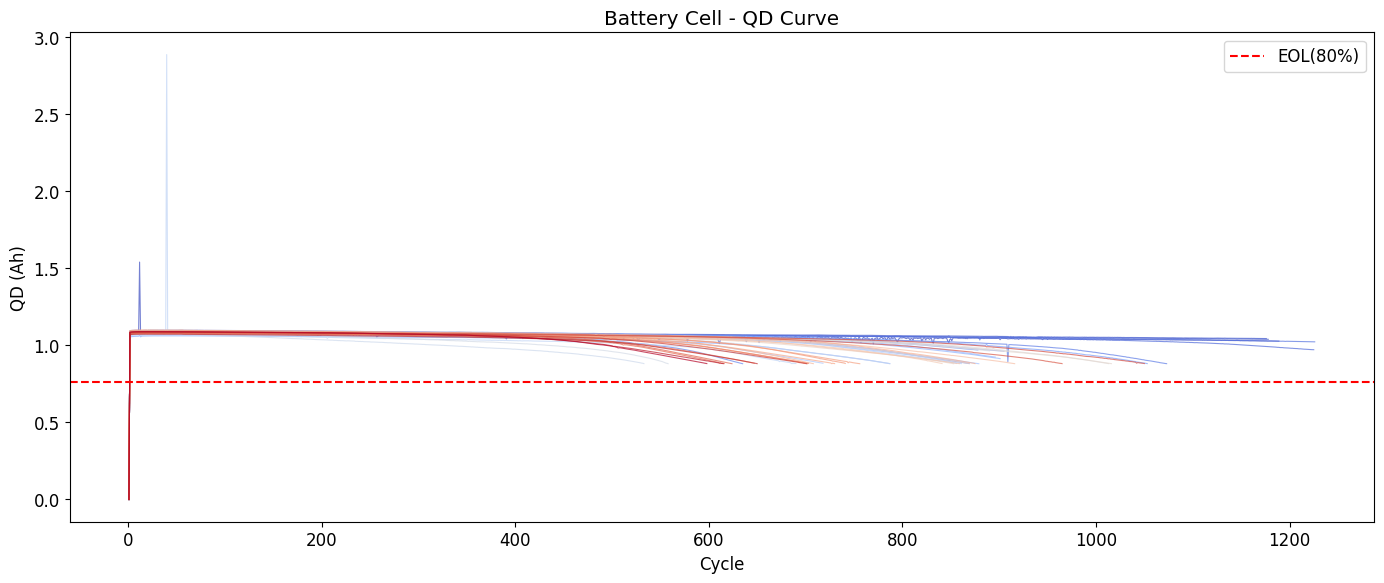

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


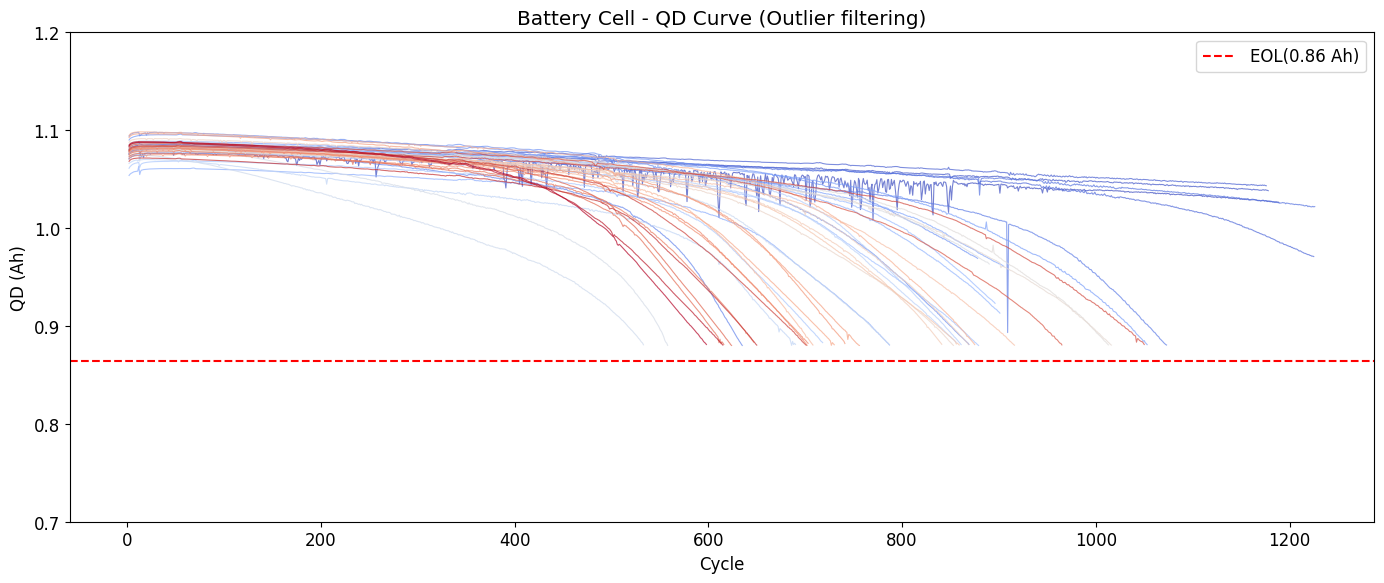

In [32]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 달느 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

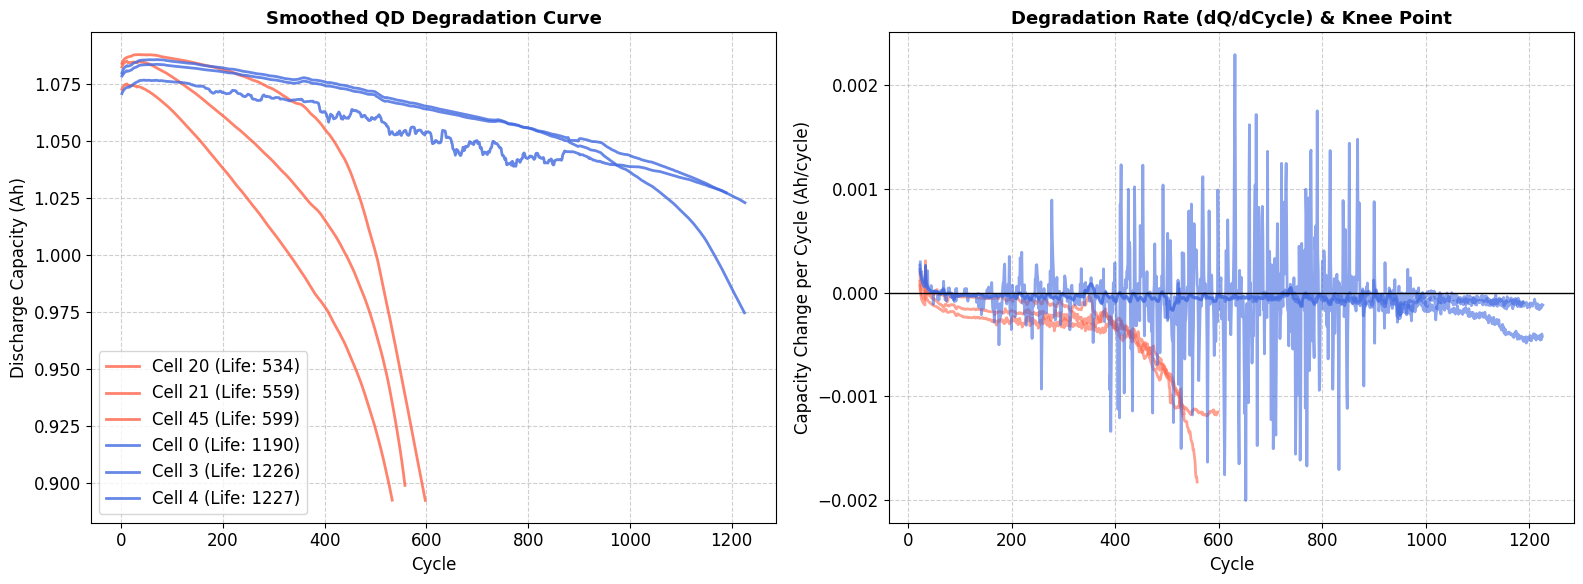

In [33]:
# 열화 속도(Degradation Rate) 및 Knee Point 탐색

# 1. 비교를 위한 극단적 샘플 추출 (가장 짧은 셀 3개, 가장 긴 셀 3개)
cycle_life_summary = df_clean.groupby('cell_id')['cycle_life'].first().sort_values()
short_cells = cycle_life_summary.head(3).index.tolist()
long_cells = cycle_life_summary.tail(3).index.tolist()
sample_cells = short_cells + long_cells

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 평활화(Smoothing) 윈도우 사이즈
window_size = 20 

for cid in sample_cells:
    sub = df_clean[df_clean['cell_id'] == cid].sort_values('cycle')
    
    # 노이즈 제거를 위한 이동 평균 적용
    smoothed_QD = sub['QD'].rolling(window=window_size, min_periods=1).mean()
    
    # 열화 속도 (1사이클 당 용량 변화량, 미분값)
    # 음수 값이 클수록 열화 속도가 빠름을 의미
    dq_dcycle = smoothed_QD.diff()
    
    # 색상 및 라벨 설정
    life = sub['cycle_life'].iloc[0]
    is_short = cid in short_cells
    color = 'tomato' if is_short else 'royalblue'
    label = f'Cell {cid} (Life: {life})' if is_short else f'Cell {cid} (Life: {life})'
    
    # [Plot 1] 평활화된 용량(QD) 곡선
    axes[0].plot(sub['cycle'], smoothed_QD, color=color, linewidth=2, alpha=0.8, label=label)
    
    # [Plot 2] 열화 속도 (dQ/dCycle) 곡선
    # 초기 노이즈를 피하기 위해 앞부분 일부 슬라이싱
    axes[1].plot(sub['cycle'][window_size:], dq_dcycle[window_size:], color=color, linewidth=2, alpha=0.6)

# Plot 1 세팅
axes[0].set_title('Smoothed QD Degradation Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Discharge Capacity (Ah)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 중복 라벨 제거용 핸들러
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys())

# Plot 2 세팅
axes[1].set_title('Degradation Rate (dQ/dCycle) & Knee Point', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Capacity Change per Cycle (Ah/cycle)')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

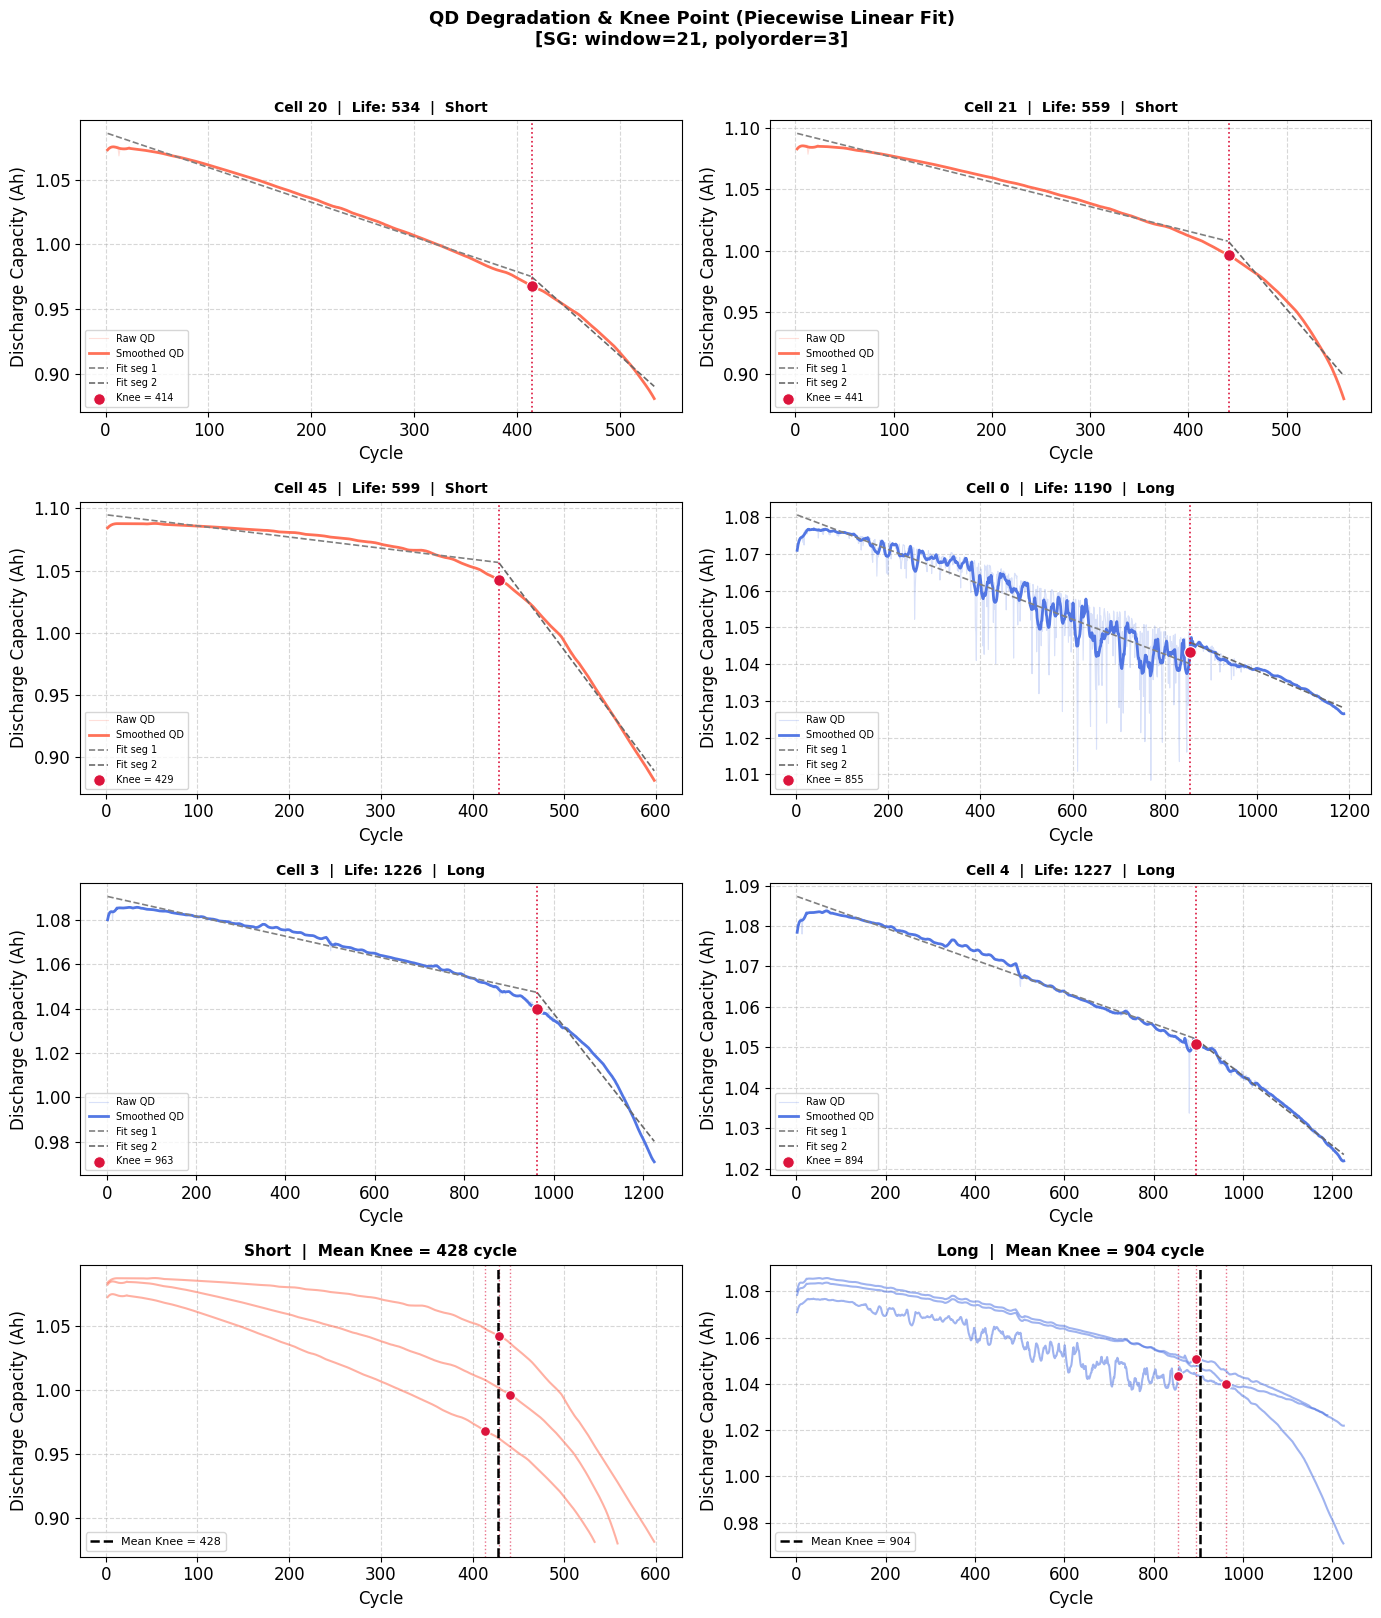


[Knee Point 요약]  (기준: Piecewise Linear Fit  |  SG window=21, polyorder=3)
  Cell    Life     Group   Knee Cycle    QD at Knee
----------------------------------------------------
    20     534     Short          414       0.96793
    21     559     Short          441       0.99654
    45     599     Short          429       1.04250
  → Short 그룹 평균 Knee : 428 cycle

     0    1190      Long          855       1.04326
     3    1226      Long          963       1.03978
     4    1227      Long          894       1.05090
  → Long 그룹 평균 Knee : 904 cycle



In [75]:
from scipy.signal import savgol_filter

# ── 파라미터 ──────────────────────────────────────────────────────────────
SG_WINDOW       = 21
SG_POLYORDER    = 3
MIN_CYCLE       = 50
MAX_CYCLE_RATIO = 0.95
MARGIN          = 20
# ──────────────────────────────────────────────────────────────────────────


def sg_smooth(arr, window=SG_WINDOW, polyorder=SG_POLYORDER):
    w = min(window, len(arr))
    if w % 2 == 0:
        w -= 1
    if w < polyorder + 2:
        return arr
    return savgol_filter(arr, window_length=w, polyorder=polyorder)


def find_knee_piecewise(x, y_smooth, min_cycle=MIN_CYCLE,
                        max_cycle_ratio=MAX_CYCLE_RATIO, margin=MARGIN):
    n         = len(x)
    start_idx = np.searchsorted(x, min_cycle)
    end_idx   = int(n * max_cycle_ratio)
    best_idx  = start_idx + margin
    best_err  = np.inf
    for k in range(start_idx + margin, end_idx - margin):
        x1, y1 = x[:k], y_smooth[:k]
        x2, y2 = x[k:], y_smooth[k:]
        p1 = np.polyfit(x1, y1, 1)
        p2 = np.polyfit(x2, y2, 1)
        err = (np.sum((y1 - np.polyval(p1, x1)) ** 2) +
               np.sum((y2 - np.polyval(p2, x2)) ** 2))
        if err < best_err:
            best_err = err
            best_idx = k
    return best_idx


# ── 셀 선택 ───────────────────────────────────────────────────────────────
cycle_life_summary = df_clean.groupby('cell_id')['cycle_life'].first().sort_values()
short_cells  = cycle_life_summary.head(3).index.tolist()
long_cells   = cycle_life_summary.tail(3).index.tolist()
sample_cells = short_cells + long_cells

# ── Knee point 미리 계산 (셀별 subplot + 그룹 비교 공용) ──────────────────
knee_results = {}
for cid in sample_cells:
    sub       = df_clean[df_clean['cell_id'] == cid].sort_values('cycle').reset_index(drop=True)
    x         = sub['cycle'].values
    qd        = sub['QD'].values
    qd_smooth = sg_smooth(qd)
    knee_idx  = find_knee_piecewise(x, qd_smooth)
    x1, y1    = x[:knee_idx], qd_smooth[:knee_idx]
    x2, y2    = x[knee_idx:], qd_smooth[knee_idx:]
    knee_results[cid] = {
        'life'      : int(sub['cycle_life'].iloc[0]),
        'group'     : 'Short' if cid in short_cells else 'Long',
        'color'     : 'tomato' if cid in short_cells else 'royalblue',
        'x'         : x,
        'qd'        : qd,
        'qd_smooth' : qd_smooth,
        'knee_idx'  : knee_idx,
        'knee_cycle': x[knee_idx],
        'knee_qd'   : qd_smooth[knee_idx],
        'p1'        : np.polyfit(x1, y1, 1),
        'p2'        : np.polyfit(x2, y2, 1),
        'x1'        : x1, 'x2': x2,
    }


# ── Figure 구성: 셀별 subplot(위) + 그룹 비교 subplot(아래) ───────────────
n_cells   = len(sample_cells)
n_cols    = 2
n_rows    = (n_cells + 1) // n_cols
total_rows = n_rows + 1   # 마지막 행: 그룹 비교 2개

fig, axes = plt.subplots(total_rows, n_cols,
                         figsize=(14, 4 * total_rows))
fig.suptitle(
    f'QD Degradation & Knee Point (Piecewise Linear Fit)\n'
    f'[SG: window={SG_WINDOW}, polyorder={SG_POLYORDER}]',
    fontsize=13, fontweight='bold', y=1.01
)

# ── 셀별 subplot ──────────────────────────────────────────────────────────
for i, cid in enumerate(sample_cells):
    ax  = axes[i // n_cols][i % n_cols]
    kr  = knee_results[cid]

    ax.plot(kr['x'], kr['qd'],        color=kr['color'], linewidth=0.8, alpha=0.2, label='Raw QD')
    ax.plot(kr['x'], kr['qd_smooth'], color=kr['color'], linewidth=2,   alpha=0.9, label='Smoothed QD')
    ax.plot(kr['x1'], np.polyval(kr['p1'], kr['x1']),
            color='gray',    linewidth=1.2, linestyle='--', label='Fit seg 1')
    ax.plot(kr['x2'], np.polyval(kr['p2'], kr['x2']),
            color='dimgray', linewidth=1.2, linestyle='--', label='Fit seg 2')
    ax.axvline(kr['knee_cycle'], color='crimson', linewidth=1.2, linestyle=':')
    ax.scatter(kr['knee_cycle'], kr['knee_qd'],
               color='crimson', s=70, zorder=5, edgecolors='white', linewidths=0.8,
               label=f"Knee = {int(kr['knee_cycle'])}")

    ax.set_title(f"Cell {cid}  |  Life: {kr['life']}  |  {kr['group']}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Discharge Capacity (Ah)')
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, linestyle='--', alpha=0.5)

# 셀별 subplot 남은 칸 제거
for j in range(n_cells, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols][j % n_cols])


# ── 그룹 비교 subplot (마지막 행) ─────────────────────────────────────────
ax_short = axes[n_rows][0]
ax_long  = axes[n_rows][1]

group_axes = [
    (ax_short, 'Short',  short_cells, 'tomato'),
    (ax_long,  'Long',   long_cells,  'royalblue'),
]

for ax, title, cell_list, color in group_axes:
    knee_cycles = []
    for cid in cell_list:
        kr = knee_results[cid]
        ax.plot(kr['x'], kr['qd_smooth'],
                color=color, linewidth=1.5, alpha=0.5)
        ax.axvline(kr['knee_cycle'], color='crimson',
                   linewidth=1, linestyle=':', alpha=0.6)
        ax.scatter(kr['knee_cycle'], kr['knee_qd'],
                   color='crimson', s=50, zorder=5,
                   edgecolors='white', linewidths=0.8)
        knee_cycles.append(kr['knee_cycle'])

    # 그룹 평균 Knee 수직선
    mean_knee = np.mean(knee_cycles)
    ax.axvline(mean_knee, color='black', linewidth=1.8, linestyle='--',
               label=f'Mean Knee = {int(mean_knee)}')

    ax.set_title(f'{title}  |  Mean Knee = {int(mean_knee)} cycle',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Discharge Capacity (Ah)')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ── Knee point 요약 ───────────────────────────────────────────────────────
print(f"\n[Knee Point 요약]  (기준: Piecewise Linear Fit  |  SG window={SG_WINDOW}, polyorder={SG_POLYORDER})")
print(f"{'Cell':>6}  {'Life':>6}  {'Group':>8}  {'Knee Cycle':>11}  {'QD at Knee':>12}")
print('-' * 52)

for group_name, cell_list in [('Short', short_cells), ('Long', long_cells)]:
    knees = []
    for cid in cell_list:
        kr = knee_results[cid]
        print(f"{cid:>6}  {kr['life']:>6}  {group_name:>8}  "
              f"{int(kr['knee_cycle']):>11}  {kr['knee_qd']:>12.5f}")
        knees.append(kr['knee_cycle'])
    print(f"  → {group_name} 그룹 평균 Knee : {np.mean(knees):.0f} cycle\n")

### 3. 내부 저항(IR) 변화 - 열화 지표

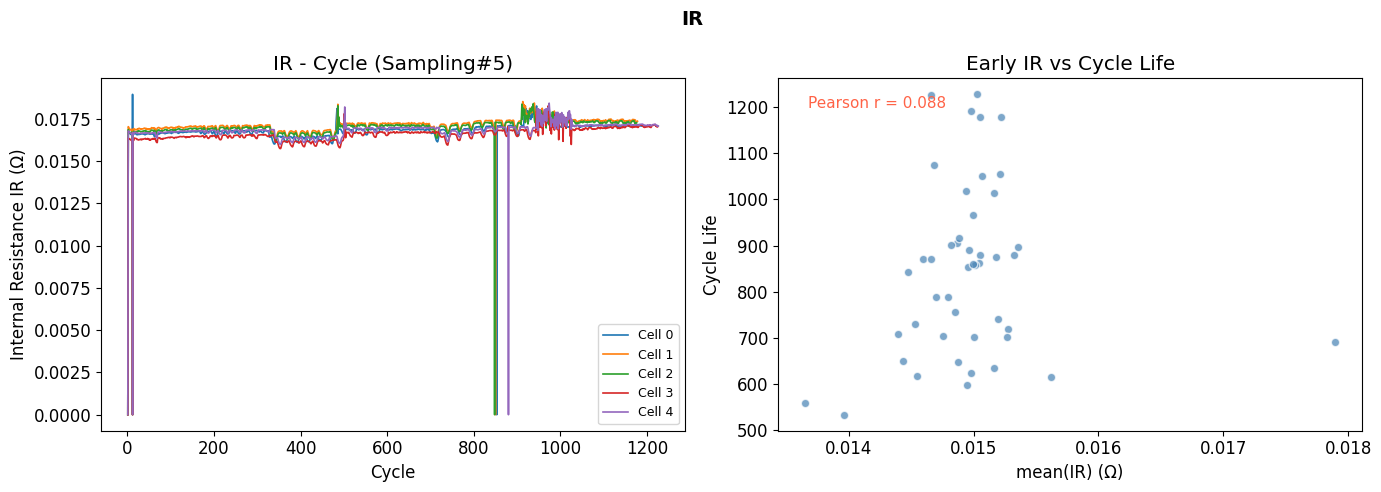

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

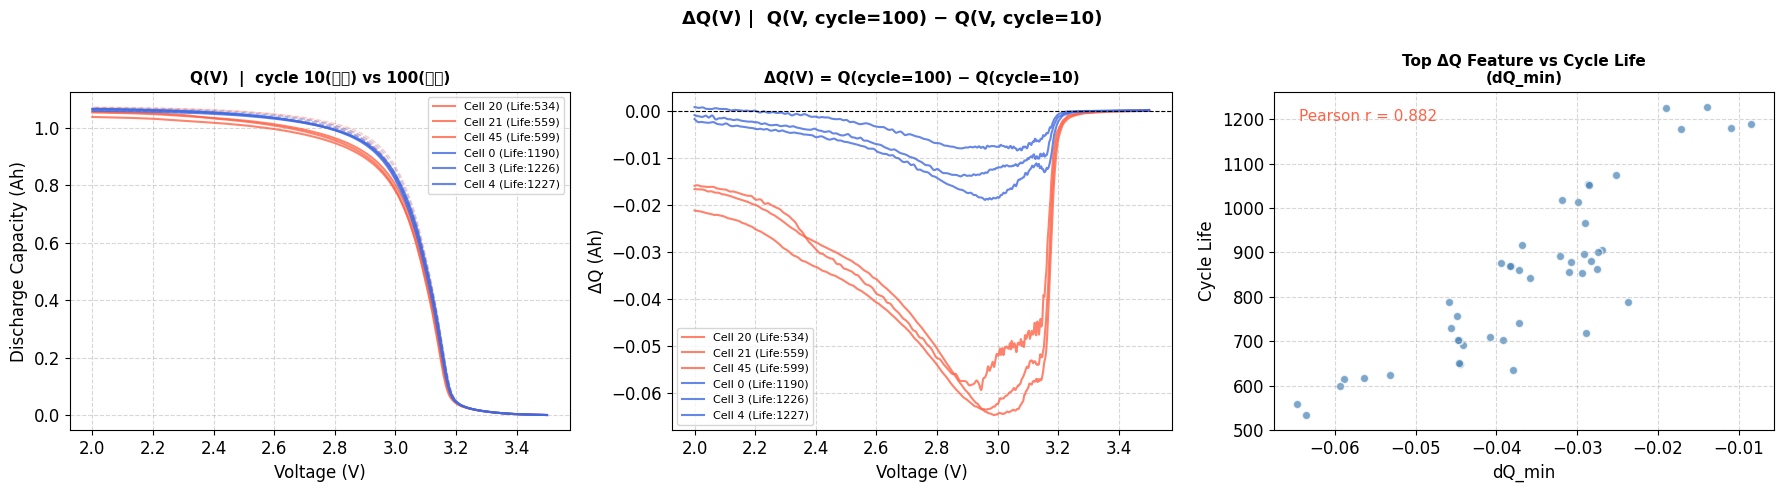


[ΔQ feature vs cycle_life corr]
dQ_min     0.882
dQ_mean    0.854
dQ_var    -0.838
dQ_skew   -0.585
dQ_kurt    0.304

[feat_df shape] (46, 7)
   cell_id  cycle_life   dQ_mean    dQ_var    dQ_min   dQ_skew   dQ_kurt
0        0        1190 -0.002873  0.000010 -0.008460 -0.532858 -1.349054
1        1        1179 -0.004100  0.000010 -0.011004 -0.430020 -1.028256
2        2        1177 -0.004487  0.000018 -0.017216 -1.081818  0.356410
3        3        1226 -0.007456  0.000036 -0.018961 -0.439710 -1.094889
4        4        1227 -0.005750  0.000023 -0.013958 -0.363093 -1.334500


In [48]:
# ── ΔQ(V) 곡선 분석 ───────────────────────────────────────────────────────
# batch[i]['cycles']['Qdlin'][n] : n번째 사이클의 전압 구간별 누적 방전 용량 (1000포인트)
# ΔQ(V) = Q(V, cycle=100) - Q(V, cycle=10)

CYCLE_A = 10    # 기준 사이클
CYCLE_B = 100   # 비교 사이클

cycle_life_summary = df_clean.groupby('cell_id')['cycle_life'].first().sort_values()
short_cells = cycle_life_summary.head(3).index.tolist()
long_cells  = cycle_life_summary.tail(3).index.tolist()
sample_cells = short_cells + long_cells


def get_qdlin(cell_idx, cycle_num):
    """batch에서 특정 셀의 특정 사이클 Qdlin 추출"""
    cycles_raw = batch[cell_idx]['cycles']
    if isinstance(cycles_raw, dict):
        keys = list(cycles_raw.keys())
        n_cycles = len(cycles_raw[keys[0]])
        cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    else:
        cycles = cycles_raw

    idx = cycle_num - 1   # 0-based index
    if idx >= len(cycles):
        return None
    qdlin = cycles[idx].get('Qdlin')
    if qdlin is None or not isinstance(qdlin, np.ndarray):
        return None
    return qdlin.flatten()


# ── 1. ΔQ(V) 곡선 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ΔQ(V) |  Q(V, cycle=100) − Q(V, cycle=10)',
             fontsize=13, fontweight='bold')

color_map = {'short': 'tomato', 'long': 'royalblue'}

for cid in sample_cells:
    is_short = cid in short_cells
    color    = color_map['short'] if is_short else color_map['long']
    group    = 'Short' if is_short else 'Long'
    life     = cycle_life_summary[cid]
    label    = f'Cell {cid} (Life:{int(life)})'

    q_a = get_qdlin(cid, CYCLE_A)
    q_b = get_qdlin(cid, CYCLE_B)

    if q_a is None or q_b is None:
        print(f"Cell {cid}: Qdlin 없음 (사이클 수 부족)")
        continue

    # 길이 맞추기
    min_len = min(len(q_a), len(q_b))
    q_a, q_b = q_a[:min_len], q_b[:min_len]
    dq = q_b - q_a
    v_idx = np.arange(min_len)   # 전압 구간 인덱스 (Vdlin 공통)

    # [좌] cycle 10 vs 100 QD(V) 원본
    axes[0].plot(v_idx, q_a, color=color, linewidth=1,   alpha=0.4, linestyle='--')
    axes[0].plot(v_idx, q_b, color=color, linewidth=1.5, alpha=0.8, label=label)

    # [중] ΔQ(V) 곡선
    axes[1].plot(v_idx, dq, color=color, linewidth=1.5, alpha=0.8, label=label)

# Vdlin(공통 전압 축) 사용 가능하면 x축 교체
vdlin = batch[0].get('Vdlin')
if vdlin is not None:
    vdlin = np.array(vdlin).flatten()
    x_label = 'Voltage (V)'
else:
    vdlin   = None
    x_label = 'Voltage index'

# x축 실제 전압으로 재플롯 (Vdlin 있을 때)
if vdlin is not None:
    axes[0].cla()
    axes[1].cla()
    for cid in sample_cells:
        is_short = cid in short_cells
        color    = color_map['short'] if is_short else color_map['long']
        life     = cycle_life_summary[cid]
        label    = f'Cell {cid} (Life:{int(life)})'

        q_a = get_qdlin(cid, CYCLE_A)
        q_b = get_qdlin(cid, CYCLE_B)
        if q_a is None or q_b is None:
            continue
        min_len = min(len(q_a), len(q_b), len(vdlin))
        q_a, q_b, v = q_a[:min_len], q_b[:min_len], vdlin[:min_len]
        dq = q_b - q_a

        axes[0].plot(v, q_a, color=color, linewidth=1,   alpha=0.35, linestyle='--')
        axes[0].plot(v, q_b, color=color, linewidth=1.5, alpha=0.8,  label=label)
        axes[1].plot(v, dq,  color=color, linewidth=1.5, alpha=0.8,  label=label)

axes[0].set_title(f'Q(V)  |  cycle {CYCLE_A}(점선) vs {CYCLE_B}(실선)', fontsize=11, fontweight='bold')
axes[0].set_xlabel(x_label)
axes[0].set_ylabel('Discharge Capacity (Ah)')
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(f'ΔQ(V) = Q(cycle={CYCLE_B}) − Q(cycle={CYCLE_A})', fontsize=11, fontweight='bold')
axes[1].set_xlabel(x_label)
axes[1].set_ylabel('ΔQ (Ah)')
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.5)


# ── 2. ΔQ 통계 피처 추출 ─────────────────────────────────────────────────
feature_records = []

for cid in df_clean['cell_id'].unique():
    life = df_clean[df_clean['cell_id'] == cid]['cycle_life'].iloc[0]

    q_a = get_qdlin(cid, CYCLE_A)
    q_b = get_qdlin(cid, CYCLE_B)
    if q_a is None or q_b is None:
        continue

    min_len = min(len(q_a), len(q_b))
    dq = q_b[:min_len] - q_a[:min_len]

    feature_records.append({
        'cell_id'    : cid,
        'cycle_life' : life,
        'dQ_mean'    : np.mean(dq),        # 평균 변화량
        'dQ_var'     : np.var(dq),         # 분산 (Severson 2019 핵심 피처)
        'dQ_min'     : np.min(dq),         # 최솟값 (열화 가속 구간)
        'dQ_skew'    : pd.Series(dq).skew(),   # 왜도
        'dQ_kurt'    : pd.Series(dq).kurt(),   # 첨도
    })

feat_df = pd.DataFrame(feature_records)

# 피처별 cycle_life 상관계수
corr = feat_df.drop(columns='cell_id').corr()['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False)

# [우] 피처 vs cycle_life scatter (가장 강한 피처)
top_feat = corr.index[0]
axes[2].scatter(feat_df[top_feat], feat_df['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[2].set_xlabel(top_feat)
axes[2].set_ylabel('Cycle Life')
axes[2].set_title(f'Top ΔQ Feature vs Cycle Life\n({top_feat})', fontsize=11, fontweight='bold')
r = feat_df[top_feat].corr(feat_df['cycle_life'])
axes[2].text(0.05, 0.95, f'Pearson r = {r:.3f}',
             transform=axes[2].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ── 3. 피처 상관계수 요약 출력 ────────────────────────────────────────────
print("\n[ΔQ feature vs cycle_life corr]")
print(corr.round(3).to_string())
print(f"\n[feat_df shape] {feat_df.shape}")
print(feat_df.head())

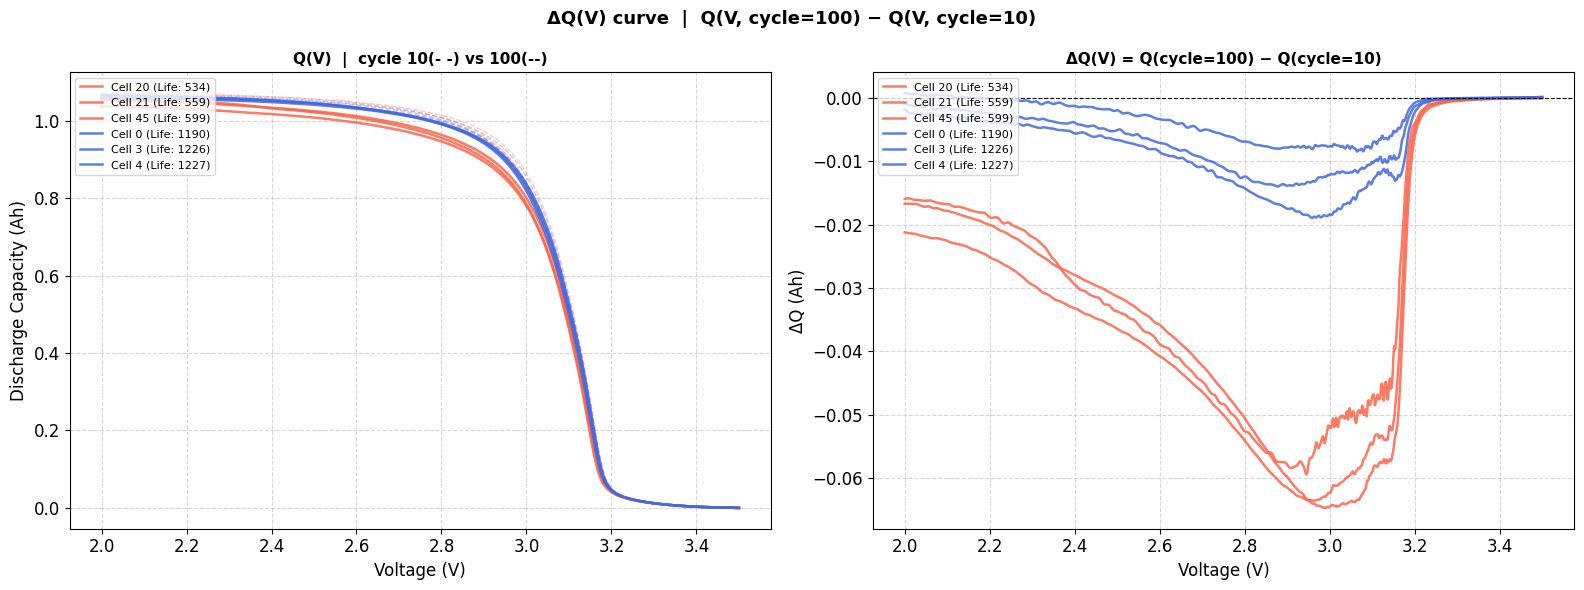


[ΔQ feature vs cycle_life Corr]
         Pearson r  Spearman r
dQ_min       0.882       0.850
dQ_mean      0.854       0.828
dQ_var      -0.838      -0.871
dQ_skew     -0.585      -0.556
dQ_kurt      0.304       0.219

★ 가장 강한 피처 : dQ_min  (Pearson r = 0.882, Spearman r = 0.850)


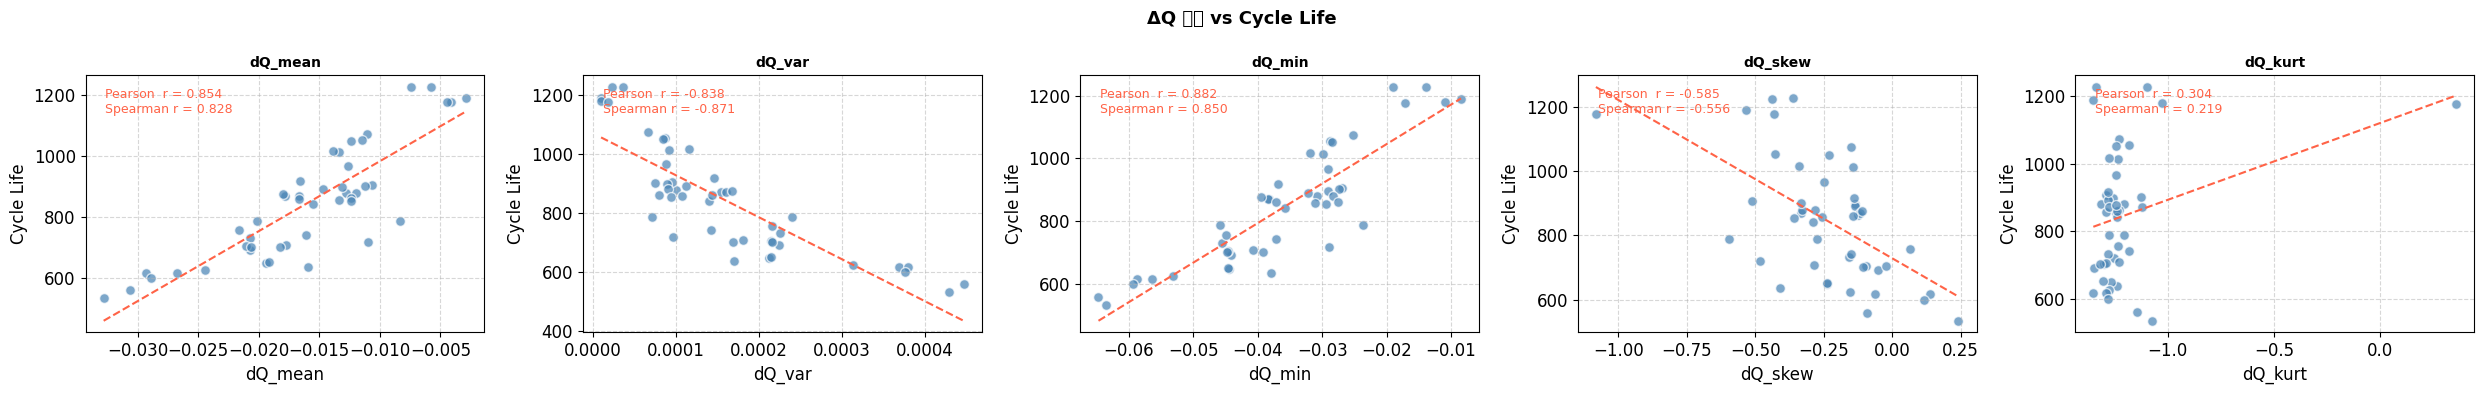

In [59]:
# ── ΔQ(V) 곡선 분석 ───────────────────────────────────────────────────────
# Qdlin: 1000개 전압 구간(Vdlin)에서의 선형 보간된 방전 용량
# batch[cell_idx]['cycles']['Qdlin'] → list of 1000-point arrays (mat73 구조)

CYCLE_A = 10    # 기준 사이클
CYCLE_B = 100   # 비교 사이클


def get_qdlin(cell_idx, cycle_num):
    """
    mat73 구조에서 Qdlin 추출.
    cycles가 dict-of-lists 형태이므로 직접 키 접근.
    """
    cycles_raw = batch[cell_idx]['cycles']

    if isinstance(cycles_raw, dict):
        qdlin_list = cycles_raw.get('Qdlin', [])
        idx = cycle_num - 1
        if idx >= len(qdlin_list):
            return None
        val = qdlin_list[idx]
    else:
        idx = cycle_num - 1
        if idx >= len(cycles_raw):
            return None
        val = cycles_raw[idx].get('Qdlin')

    if val is None:
        return None
    arr = np.array(val).flatten()
    return arr if len(arr) > 0 else None


# Vdlin: 공통 전압 구간 (1000포인트)
vdlin = np.array(batch[0]['Vdlin']).flatten()

# ── 셀 선택 ───────────────────────────────────────────────────────────────
cycle_life_summary = df_clean.groupby('cell_id')['cycle_life'].first().sort_values()
short_cells  = cycle_life_summary.head(3).index.tolist()
long_cells   = cycle_life_summary.tail(3).index.tolist()
sample_cells = short_cells + long_cells


# ── 1. ΔQ(V) 곡선 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'ΔQ(V) curve  |  Q(V, cycle={CYCLE_B}) − Q(V, cycle={CYCLE_A})',
             fontsize=13, fontweight='bold')

for cid in sample_cells:
    is_short = cid in short_cells
    color    = 'tomato' if is_short else 'royalblue'
    life     = cycle_life_summary[cid]
    label    = f'Cell {cid} (Life: {int(life)})'

    q_a = get_qdlin(cid, CYCLE_A)
    q_b = get_qdlin(cid, CYCLE_B)

    if q_a is None or q_b is None:
        print(f"Cell {cid}: Qdlin null")
        continue

    min_len   = min(len(q_a), len(q_b), len(vdlin))
    v         = vdlin[:min_len]
    dq        = q_b[:min_len] - q_a[:min_len]

    # 좌: Q(V) cycle 10 vs 100
    axes[0].plot(v, q_a[:min_len], color=color, linewidth=1,   alpha=0.35, linestyle='--')
    axes[0].plot(v, q_b[:min_len], color=color, linewidth=1.8, alpha=0.85, label=label)

    # 우: ΔQ(V)
    axes[1].plot(v, dq, color=color, linewidth=1.8, alpha=0.85, label=label)

axes[0].set_title(f'Q(V)  |  cycle {CYCLE_A}(- -) vs {CYCLE_B}(--)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Voltage (V)')
axes[0].set_ylabel('Discharge Capacity (Ah)')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(f'ΔQ(V) = Q(cycle={CYCLE_B}) − Q(cycle={CYCLE_A})', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Voltage (V)')
axes[1].set_ylabel('ΔQ (Ah)')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ── 2. ΔQ 통계 피처 추출 (전체 셀) ──────────────────────────────────────
feature_records = []

for cid in df_clean['cell_id'].unique():
    life = df_clean[df_clean['cell_id'] == cid]['cycle_life'].iloc[0]

    q_a = get_qdlin(cid, CYCLE_A)
    q_b = get_qdlin(cid, CYCLE_B)
    if q_a is None or q_b is None:
        continue

    min_len = min(len(q_a), len(q_b))
    dq      = q_b[:min_len] - q_a[:min_len]

    feature_records.append({
        'cell_id'   : cid,
        'cycle_life': life,
        'dQ_mean'   : np.mean(dq),
        'dQ_var'    : np.var(dq),       # Severson 2019 핵심 피처
        'dQ_min'    : np.min(dq),
        'dQ_skew'   : pd.Series(dq).skew(),
        'dQ_kurt'   : pd.Series(dq).kurt(),
    })

feat_df = pd.DataFrame(feature_records)

# ── 3. 피처 vs cycle_life 상관계수 ───────────────────────────────────────
feat_cols = ['dQ_mean', 'dQ_var', 'dQ_min', 'dQ_skew', 'dQ_kurt']
pearson   = feat_df[feat_cols + ['cycle_life']].corr(method='pearson')['cycle_life'].drop('cycle_life')
spearman  = feat_df[feat_cols + ['cycle_life']].corr(method='spearman')['cycle_life'].drop('cycle_life')

corr_summary = pd.DataFrame({
    'Pearson r' : pearson,
    'Spearman r': spearman,
}).sort_values('Pearson r', key=abs, ascending=False)

print("\n[ΔQ feature vs cycle_life Corr]")
print(corr_summary.round(3).to_string())

top_feat = corr_summary.index[0]
print(f"\n★ 가장 강한 피처 : {top_feat}  "
      f"(Pearson r = {pearson[top_feat]:.3f}, Spearman r = {spearman[top_feat]:.3f})")

# ── 4. Top 피처 scatter ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(feat_cols), figsize=(5 * len(feat_cols), 4))
fig.suptitle('ΔQ 피처 vs Cycle Life', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, feat_cols):
    ax.scatter(feat_df[feat], feat_df['cycle_life'],
               alpha=0.7, color='steelblue', edgecolors='white', s=50)
    m, b = np.polyfit(feat_df[feat], feat_df['cycle_life'], 1)
    x_line = np.linspace(feat_df[feat].min(), feat_df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, linestyle='--')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Cycle Life')
    ax.text(0.05, 0.95,
            f'Pearson  r = {pearson[feat]:.3f}\nSpearman r = {spearman[feat]:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', color='tomato')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

  Q(V) 차이 수치 요약  |  ΔQ = Q(cycle=100) − Q(cycle=10)
  Cell    Life     Group   Q_10 mean   Q_100 mean    ΔQ mean     ΔQ min     ΔQ max
---------------------------------------------------------------------------
    20     534     Short      0.7498       0.7170    -0.0328    -0.0636     0.0000
    21     559     Short      0.7614       0.7308    -0.0307    -0.0647    -0.0000
    45     599     Short      0.7542       0.7253    -0.0289    -0.0594     0.0001
     0    1190      Long      0.7482       0.7453    -0.0029    -0.0085     0.0008
     3    1226      Long      0.7572       0.7498    -0.0075    -0.0190     0.0002
     4    1227      Long      0.7506       0.7448    -0.0058    -0.0140     0.0000
---------------------------------------------------------------------------
  Short 그룹 ΔQ mean 평균 : -0.0308 Ah
  Long  그룹 ΔQ mean 평균 : -0.0054 Ah
  그룹 간 차이            : 0.0254 Ah


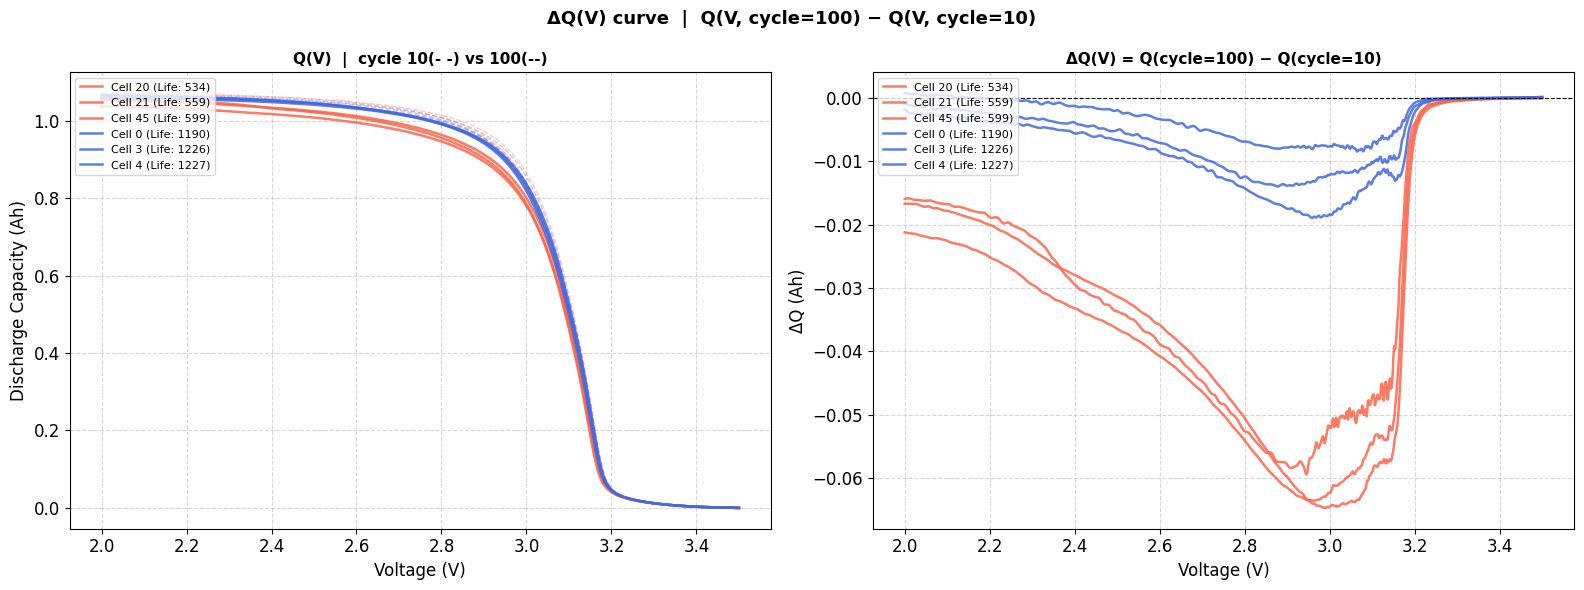


[ΔQ feature vs cycle_life Corr]
         Pearson r  Spearman r
dQ_min       0.882       0.850
dQ_mean      0.854       0.828
dQ_var      -0.838      -0.871
dQ_skew     -0.585      -0.556
dQ_kurt      0.304       0.219

★ 가장 강한 피처 : dQ_min  (Pearson r = 0.882, Spearman r = 0.850)


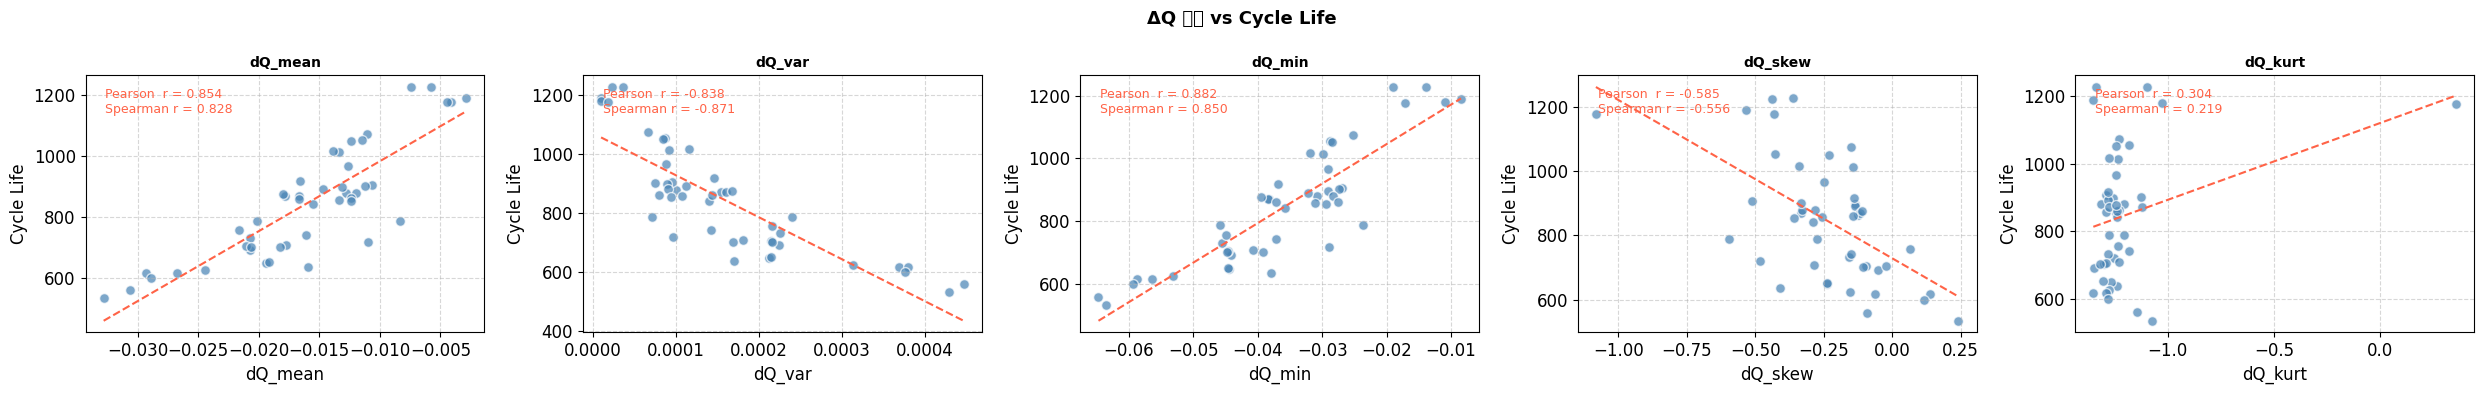

In [60]:
# ── ΔQ(V) 곡선 분석 ───────────────────────────────────────────────────────
CYCLE_A = 10
CYCLE_B = 100


def get_qdlin(cell_idx, cycle_num):
    cycles_raw = batch[cell_idx]['cycles']
    if isinstance(cycles_raw, dict):
        qdlin_list = cycles_raw.get('Qdlin', [])
        idx = cycle_num - 1
        if idx >= len(qdlin_list):
            return None
        val = qdlin_list[idx]
    else:
        idx = cycle_num - 1
        if idx >= len(cycles_raw):
            return None
        val = cycles_raw[idx].get('Qdlin')
    if val is None:
        return None
    arr = np.array(val).flatten()
    return arr if len(arr) > 0 else None


vdlin = np.array(batch[0]['Vdlin']).flatten()

cycle_life_summary = df_clean.groupby('cell_id')['cycle_life'].first().sort_values()
short_cells  = cycle_life_summary.head(3).index.tolist()
long_cells   = cycle_life_summary.tail(3).index.tolist()
sample_cells = short_cells + long_cells


# ── 1. Q(V) 차이 수치 요약 ───────────────────────────────────────────────
print("=" * 65)
print(f"  Q(V) 차이 수치 요약  |  ΔQ = Q(cycle={CYCLE_B}) − Q(cycle={CYCLE_A})")
print("=" * 65)
print(f"{'Cell':>6}  {'Life':>6}  {'Group':>8}  "
      f"{'Q_10 mean':>10}  {'Q_100 mean':>11}  {'ΔQ mean':>9}  {'ΔQ min':>9}  {'ΔQ max':>9}")
print("-" * 75)

dq_records = {}   # 시각화·피처 추출에 재사용

for cid in sample_cells:
    q_a = get_qdlin(cid, CYCLE_A)
    q_b = get_qdlin(cid, CYCLE_B)
    if q_a is None or q_b is None:
        print(f"  Cell {cid}: Qdlin null")
        continue

    min_len = min(len(q_a), len(q_b), len(vdlin))
    dq = q_b[:min_len] - q_a[:min_len]
    dq_records[cid] = (q_a[:min_len], q_b[:min_len], dq)

    life  = int(cycle_life_summary[cid])
    group = 'Short' if cid in short_cells else 'Long'
    print(f"{cid:>6}  {life:>6}  {group:>8}  "
          f"{np.mean(q_a[:min_len]):>10.4f}  "
          f"{np.mean(q_b[:min_len]):>11.4f}  "
          f"{np.mean(dq):>9.4f}  "
          f"{np.min(dq):>9.4f}  "
          f"{np.max(dq):>9.4f}")

print("-" * 75)
# 그룹별 ΔQ mean 평균 비교
short_dq_means = [np.mean(dq_records[c][2]) for c in short_cells if c in dq_records]
long_dq_means  = [np.mean(dq_records[c][2]) for c in long_cells  if c in dq_records]
print(f"  Short 그룹 ΔQ mean 평균 : {np.mean(short_dq_means):.4f} Ah")
print(f"  Long  그룹 ΔQ mean 평균 : {np.mean(long_dq_means):.4f} Ah")
print(f"  그룹 간 차이            : {abs(np.mean(short_dq_means) - np.mean(long_dq_means)):.4f} Ah")
print("=" * 65)


# ── 2. ΔQ(V) 곡선 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'ΔQ(V) curve  |  Q(V, cycle={CYCLE_B}) − Q(V, cycle={CYCLE_A})',
             fontsize=13, fontweight='bold')

for cid in sample_cells:
    if cid not in dq_records:
        continue
    q_a, q_b, dq = dq_records[cid]
    is_short = cid in short_cells
    color    = 'tomato' if is_short else 'royalblue'
    life     = cycle_life_summary[cid]
    label    = f'Cell {cid} (Life: {int(life)})'
    v        = vdlin[:len(dq)]

    axes[0].plot(v, q_a, color=color, linewidth=1,   alpha=0.35, linestyle='--')
    axes[0].plot(v, q_b, color=color, linewidth=1.8, alpha=0.85, label=label)
    axes[1].plot(v, dq,  color=color, linewidth=1.8, alpha=0.85, label=label)

axes[0].set_title(f'Q(V)  |  cycle {CYCLE_A}(- -) vs {CYCLE_B}(--)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Voltage (V)')
axes[0].set_ylabel('Discharge Capacity (Ah)')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(f'ΔQ(V) = Q(cycle={CYCLE_B}) − Q(cycle={CYCLE_A})', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Voltage (V)')
axes[1].set_ylabel('ΔQ (Ah)')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ── 3. ΔQ 통계 피처 추출 (전체 셀) ──────────────────────────────────────
feature_records = []

for cid in df_clean['cell_id'].unique():
    life = df_clean[df_clean['cell_id'] == cid]['cycle_life'].iloc[0]
    q_a  = get_qdlin(cid, CYCLE_A)
    q_b  = get_qdlin(cid, CYCLE_B)
    if q_a is None or q_b is None:
        continue
    min_len = min(len(q_a), len(q_b))
    dq      = q_b[:min_len] - q_a[:min_len]
    feature_records.append({
        'cell_id'   : cid,
        'cycle_life': life,
        'dQ_mean'   : np.mean(dq),
        'dQ_var'    : np.var(dq),
        'dQ_min'    : np.min(dq),
        'dQ_skew'   : pd.Series(dq).skew(),
        'dQ_kurt'   : pd.Series(dq).kurt(),
    })

feat_df = pd.DataFrame(feature_records)

# ── 4. 피처 vs cycle_life 상관계수 ───────────────────────────────────────
feat_cols = ['dQ_mean', 'dQ_var', 'dQ_min', 'dQ_skew', 'dQ_kurt']
pearson   = feat_df[feat_cols + ['cycle_life']].corr(method='pearson')['cycle_life'].drop('cycle_life')
spearman  = feat_df[feat_cols + ['cycle_life']].corr(method='spearman')['cycle_life'].drop('cycle_life')

corr_summary = pd.DataFrame({
    'Pearson r' : pearson,
    'Spearman r': spearman,
}).sort_values('Pearson r', key=abs, ascending=False)

print("\n[ΔQ feature vs cycle_life Corr]")
print(corr_summary.round(3).to_string())

top_feat = corr_summary.index[0]
print(f"\n★ 가장 강한 피처 : {top_feat}  "
      f"(Pearson r = {pearson[top_feat]:.3f}, Spearman r = {spearman[top_feat]:.3f})")

# ── 5. 피처 scatter ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(feat_cols), figsize=(5 * len(feat_cols), 4))
fig.suptitle('ΔQ 피처 vs Cycle Life', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, feat_cols):
    ax.scatter(feat_df[feat], feat_df['cycle_life'],
               alpha=0.7, color='steelblue', edgecolors='white', s=50)
    m, b = np.polyfit(feat_df[feat], feat_df['cycle_life'], 1)
    x_line = np.linspace(feat_df[feat].min(), feat_df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, linestyle='--')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Cycle Life')
    ax.text(0.05, 0.95,
            f'Pearson  r = {pearson[feat]:.3f}\nSpearman r = {spearman[feat]:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', color='tomato')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

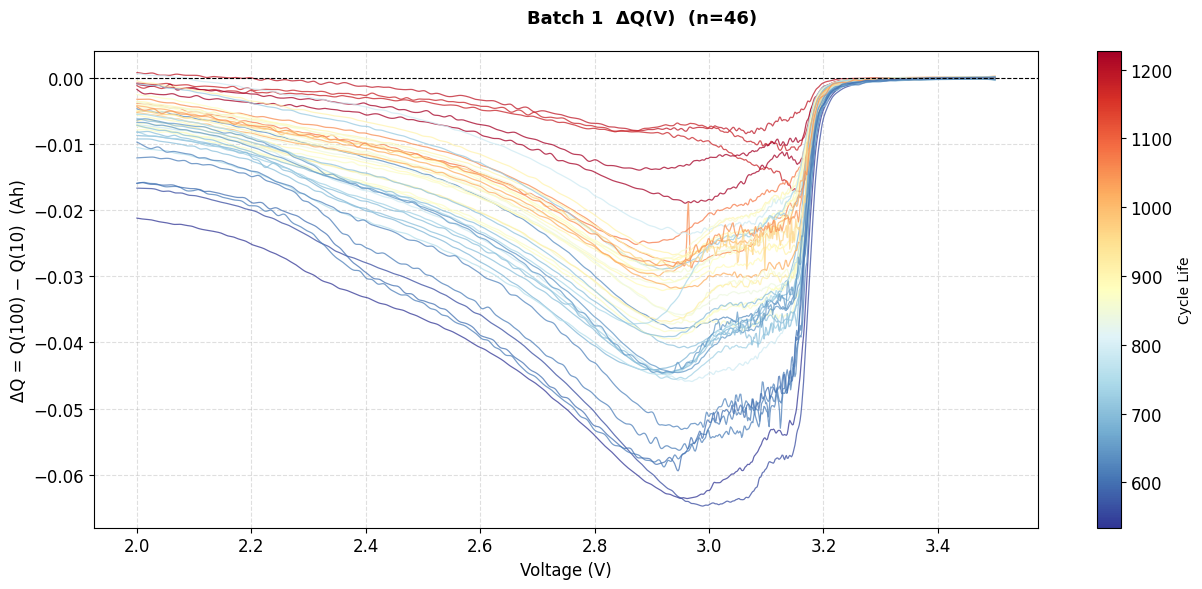

  Q(V) 차이 수치 요약  |  ΔQ = Q(cycle=100) − Q(cycle=10)
  Cell    Life   Q_10 mean   Q_100 mean    ΔQ mean     ΔQ min     ΔQ max
--------------------------------------------------------------------
     0    1190      0.7482       0.7453    -0.0029    -0.0085     0.0008
     1    1179      0.7506       0.7465    -0.0041    -0.0110    -0.0001
     2    1177      0.7554       0.7509    -0.0045    -0.0172     0.0000
     3    1226      0.7572       0.7498    -0.0075    -0.0190     0.0002
     4    1227      0.7506       0.7448    -0.0058    -0.0140     0.0000
     5    1074      0.7456       0.7345    -0.0111    -0.0252     0.0002
     6     636      0.7507       0.7347    -0.0160    -0.0379     0.0001
     7     870      0.7673       0.7507    -0.0166    -0.0382    -0.0001
     8     879      0.7622       0.7493    -0.0128    -0.0308     0.0000
     9    1054      0.7599       0.7484    -0.0115    -0.0287    -0.0000
    10     906      0.7540       0.7433    -0.0107    -0.0270     0.0001
   

In [73]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# ── ΔQ(V) 초기 사이클 차이 분석 ──────────────────────────────────────────
CYCLE_A = 10
CYCLE_B = 100


def get_qdlin(cell_idx, cycle_num):
    cycles_raw = batch[cell_idx]['cycles']
    if isinstance(cycles_raw, dict):
        qdlin_list = cycles_raw.get('Qdlin', [])
        idx = cycle_num - 1
        if idx >= len(qdlin_list):
            return None
        val = qdlin_list[idx]
    else:
        idx = cycle_num - 1
        if idx >= len(cycles_raw):
            return None
        val = cycles_raw[idx].get('Qdlin')
    if val is None:
        return None
    arr = np.array(val).flatten()
    return arr if len(arr) > 0 else None


vdlin              = np.array(batch[0]['Vdlin']).flatten()
cycle_life_summary = df_clean.groupby('cell_id')['cycle_life'].first()

# ── 컬러맵 설정 (파랑=단수명, 빨강=장수명) ───────────────────────────────
all_lives  = cycle_life_summary.values
life_min   = all_lives.min()
life_max   = all_lives.max()
cmap       = cm.RdYlBu_r                          # 파랑→빨강
norm       = mcolors.Normalize(vmin=life_min, vmax=life_max)

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle(
    f'Batch 1  ΔQ(V)  (n={len(cycle_life_summary)})',
    fontsize=13, fontweight='bold'
)

for cid in cycle_life_summary.index:
    q_a = get_qdlin(cid, CYCLE_A)
    q_b = get_qdlin(cid, CYCLE_B)
    if q_a is None or q_b is None:
        continue

    min_len = min(len(q_a), len(q_b), len(vdlin))
    v       = vdlin[:min_len]
    dq      = q_b[:min_len] - q_a[:min_len]
    life    = cycle_life_summary[cid]
    color   = cmap(norm(life))

    ax.plot(v, dq, color=color, linewidth=0.9, alpha=0.75)

# 컬러바
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Cycle Life', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('ΔQ = Q(100) − Q(10)  (Ah)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# ── 수치 요약 테이블 ──────────────────────────────────────────────────────
print("=" * 65)
print(f"  Q(V) 차이 수치 요약  |  ΔQ = Q(cycle={CYCLE_B}) − Q(cycle={CYCLE_A})")
print("=" * 65)
print(f"{'Cell':>6}  {'Life':>6}  "
      f"{'Q_10 mean':>10}  {'Q_100 mean':>11}  {'ΔQ mean':>9}  {'ΔQ min':>9}  {'ΔQ max':>9}")
print("-" * 68)

records = []
for cid in sorted(cycle_life_summary.index):
    q_a = get_qdlin(cid, CYCLE_A)
    q_b = get_qdlin(cid, CYCLE_B)
    if q_a is None or q_b is None:
        continue
    min_len = min(len(q_a), len(q_b))
    dq      = q_b[:min_len] - q_a[:min_len]
    life    = int(cycle_life_summary[cid])
    print(f"{cid:>6}  {life:>6}  "
          f"{np.mean(q_a[:min_len]):>10.4f}  "
          f"{np.mean(q_b[:min_len]):>11.4f}  "
          f"{np.mean(dq):>9.4f}  "
          f"{np.min(dq):>9.4f}  "
          f"{np.max(dq):>9.4f}")
    records.append({'cell_id': cid, 'cycle_life': life,
                    'dQ_mean': np.mean(dq), 'dQ_min': np.min(dq),
                    'dQ_max': np.max(dq)})

print("-" * 68)
print(f"  전체 ΔQ mean 평균 : {np.mean([r['dQ_mean'] for r in records]):.4f} Ah")
print(f"  전체 ΔQ min  평균 : {np.mean([r['dQ_min']  for r in records]):.4f} Ah")
print("=" * 65)

### 4. 충전 정책(C-rate)과 수명의 관계

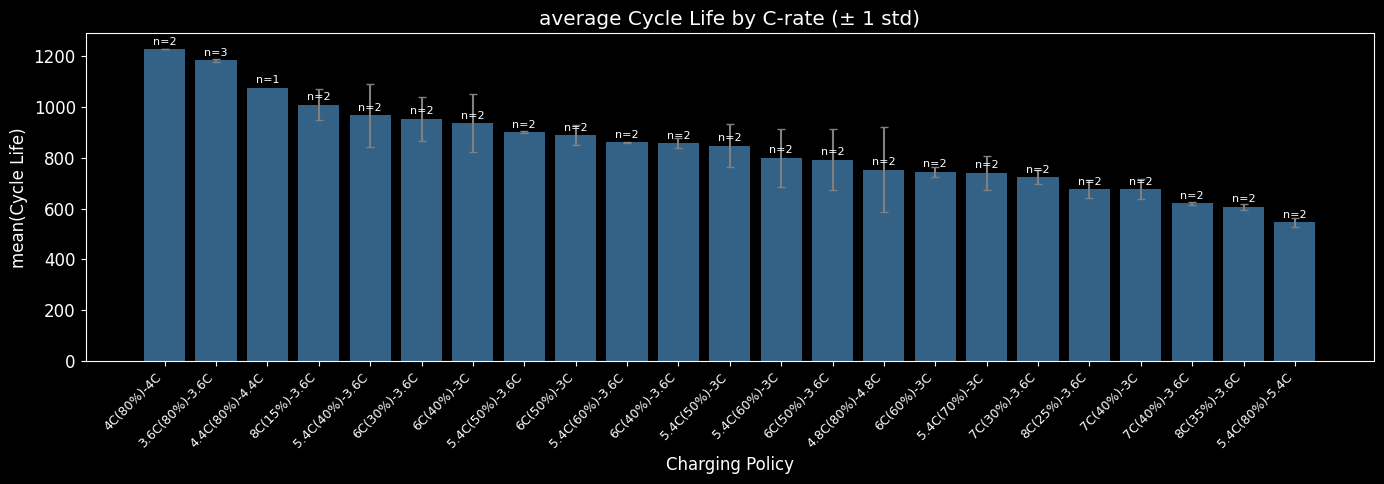

In [29]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

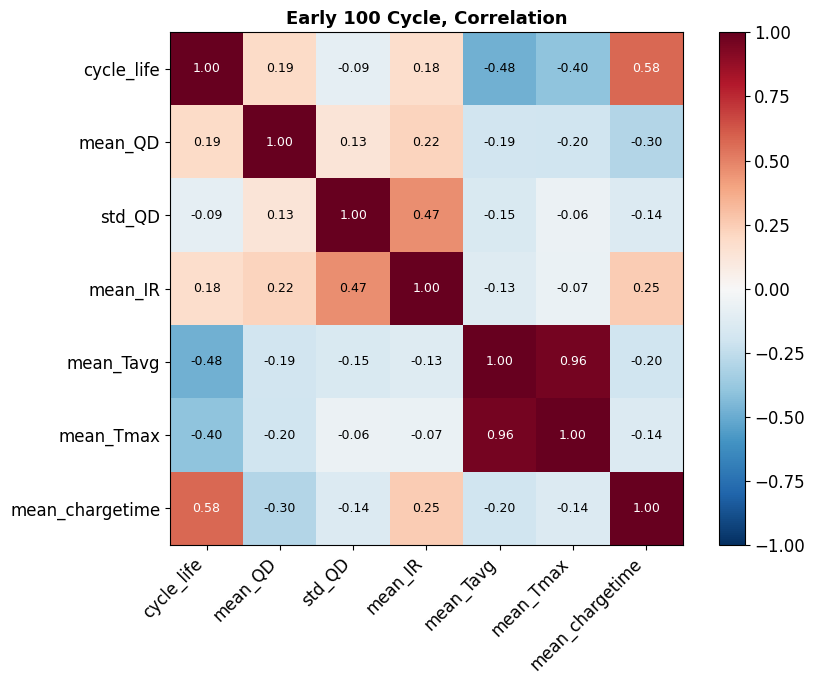


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [49]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

In [51]:
!pip install statsmodels -q

mean_Tmax 제거 완료 (mean_Tavg와 상관계수 ≈ 0.96, VIF 과다)

  잔존 피처 VIF
        feature     VIF
        mean_QD 2601.17
        mean_IR 1882.21
      mean_Tavg 1179.19
mean_chargetime   81.26
         std_QD   79.18

⚠ VIF > 10 피처 존재 → 추가 검토 필요

  잔존 피처 vs cycle_life 상관계수
                 Pearson r  Spearman r
mean_chargetime      0.577       0.613
mean_Tavg           -0.482      -0.371
mean_QD              0.193       0.185
mean_IR              0.177       0.136
std_QD              -0.090       0.237

★ 가장 강한 피처 : mean_chargetime  (Pearson r = 0.577, Spearman r = 0.613)


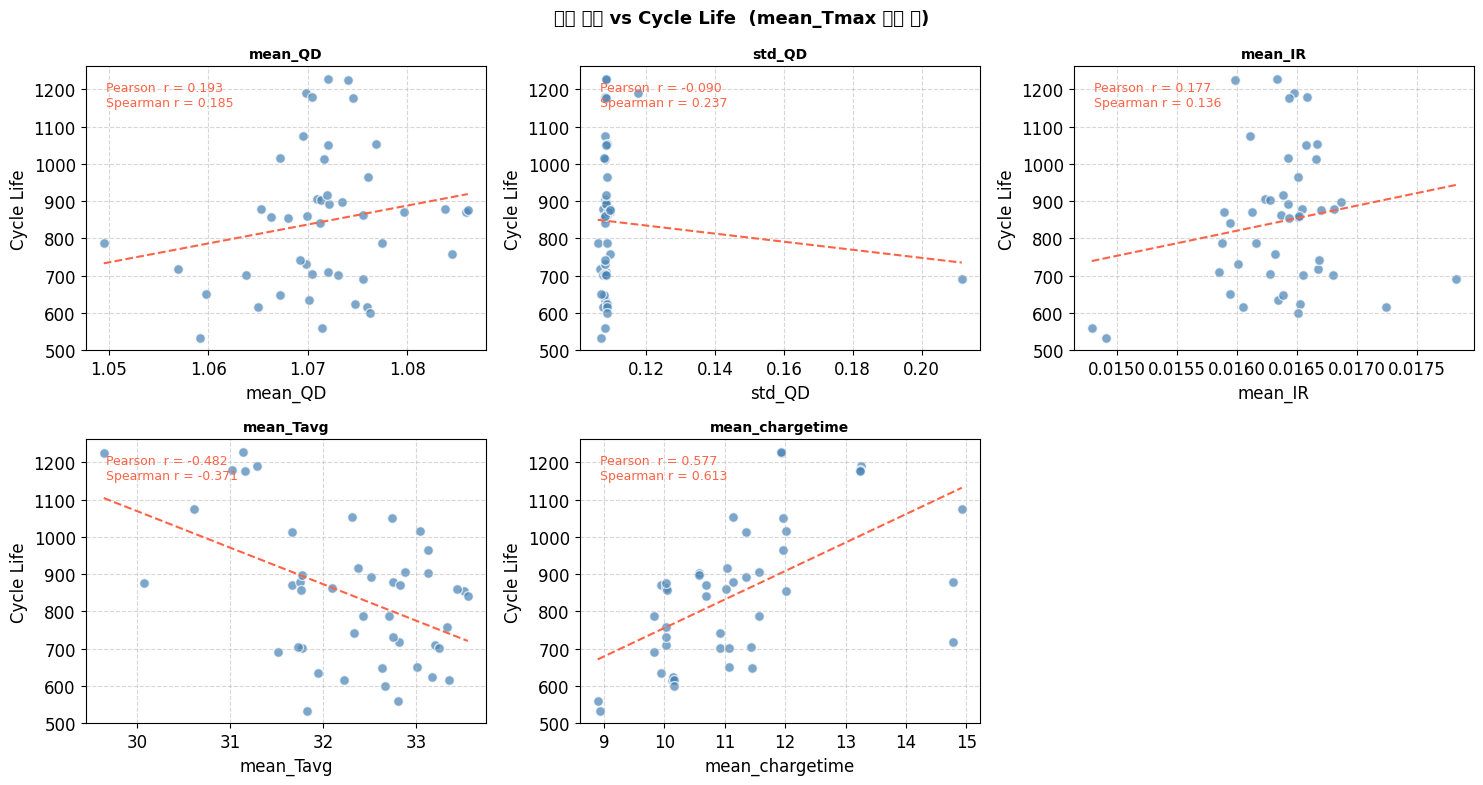

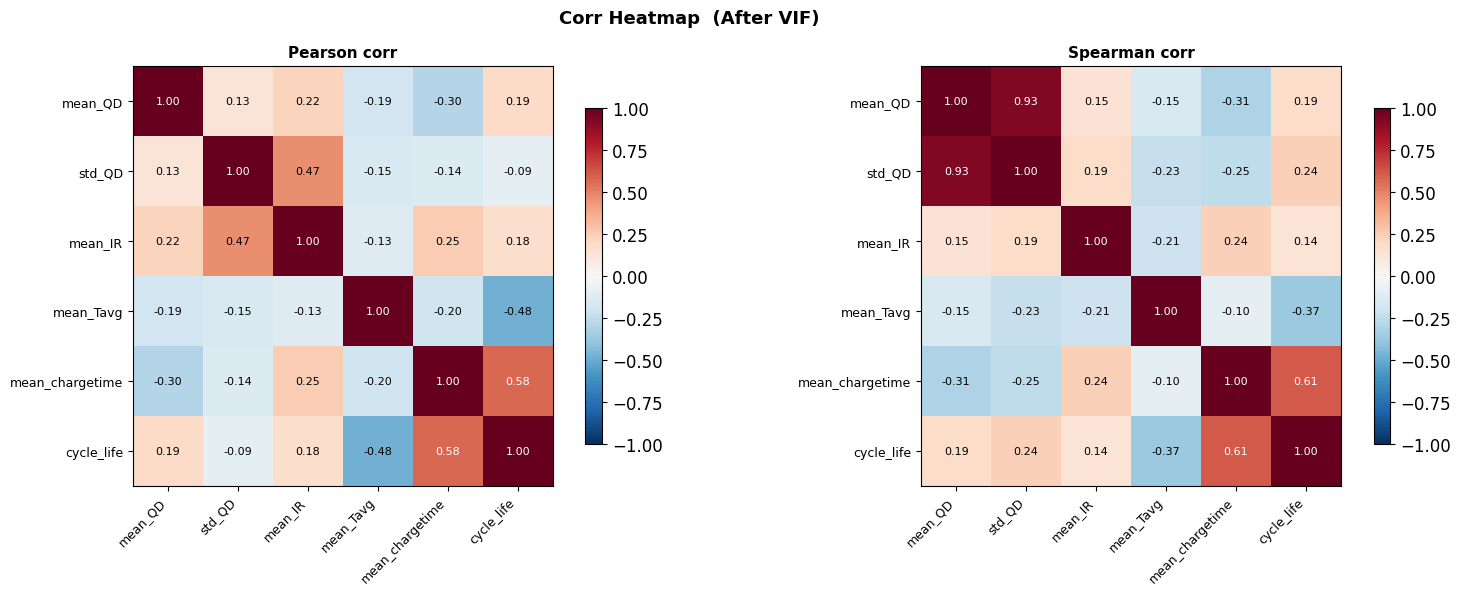

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 1. 피처 집계 ──────────────────────────────────────────────────────────
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life      = ('cycle_life', 'first'),
    mean_QD         = ('QD', 'mean'),
    std_QD          = ('QD', 'std'),
    mean_IR         = ('IR', 'mean'),
    mean_Tavg       = ('Tavg', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

# mean_Tmax 처음부터 제외 (mean_Tavg와 다중공선성, Pearson r=0.96)
feature_cols = ['mean_QD', 'std_QD', 'mean_IR', 'mean_Tavg', 'mean_chargetime']
X = early[feature_cols].copy()

print("mean_Tmax 제거 완료 (mean_Tavg와 상관계수 ≈ 0.96, VIF 과다)\n")


# ── 2. 잔존 피처 VIF 확인 ─────────────────────────────────────────────────
vif = pd.DataFrame({
    'feature': X.columns,
    'VIF'    : [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("=" * 35)
print("  잔존 피처 VIF")
print("=" * 35)
print(vif.round(2).to_string(index=False))

if vif['VIF'].max() > 10:
    print(f"\n⚠ VIF > 10 피처 존재 → 추가 검토 필요")
else:
    print(f"\n모든 피처 VIF ≤ 10 → 다중공선성 없음")


# ── 3. 잔존 피처 vs cycle_life 상관관계 ──────────────────────────────────
remain_cols = feature_cols
analysis_df = early[remain_cols + ['cycle_life']].copy()

pearson  = analysis_df.corr(method='pearson')['cycle_life'].drop('cycle_life')
spearman = analysis_df.corr(method='spearman')['cycle_life'].drop('cycle_life')

corr_summary = pd.DataFrame({
    'Pearson r' : pearson,
    'Spearman r': spearman,
    'Abs Pearson': pearson.abs(),
}).sort_values('Abs Pearson', ascending=False)

print("\n" + "=" * 35)
print("  잔존 피처 vs cycle_life 상관계수")
print("=" * 35)
print(corr_summary.drop(columns='Abs Pearson').round(3).to_string())

top_feat = corr_summary.index[0]
print(f"\n★ 가장 강한 피처 : {top_feat}  "
      f"(Pearson r = {pearson[top_feat]:.3f}, Spearman r = {spearman[top_feat]:.3f})")


# ── 4. 시각화 ─────────────────────────────────────────────────────────────
n = len(remain_cols)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
fig.suptitle('잔존 피처 vs Cycle Life  (mean_Tmax 제거 후)', fontsize=13, fontweight='bold')

for i, feat in enumerate(remain_cols):
    ax = axes[i]
    ax.scatter(analysis_df[feat], analysis_df['cycle_life'],
               alpha=0.7, color='steelblue', edgecolors='white', s=50)

    m, b = np.polyfit(analysis_df[feat], analysis_df['cycle_life'], 1)
    x_line = np.linspace(analysis_df[feat].min(), analysis_df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, linestyle='--')

    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Cycle Life')
    ax.text(0.05, 0.95,
            f'Pearson  r = {pearson[feat]:.3f}\nSpearman r = {spearman[feat]:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', color='tomato')
    ax.grid(True, linestyle='--', alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Corr Heatmap  (After VIF)', fontsize=13, fontweight='bold')

for ax, method in zip(axes, ['pearson', 'spearman']):
    corr = analysis_df.corr(method=method)
    labels = corr.columns.tolist()

    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.8)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr.iloc[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color)

    ax.set_title(f'{method.capitalize()} corr', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.